# 13 - Task 3: domain clustering, error analysis, and the transfer protocol

**What this notebook is really for.** Its visible output is a set of clusters. Its
important output is a *CV protocol*.

Every round of this project has selected models and features on 5-fold stratified CV over
the training rows. The COLING paper shows the test set is drawn from entirely different
source corpora, so that protocol scores every candidate on data from the same domains it
was fitted on. It rewards whatever memorises those domains best, which is a plausible
explanation for the project's most persistent pattern: round 3's ensemble gained 0.0017
locally and nothing on Kaggle, round 4's best combiner gained 0.0075 out-of-fold AUC and
0.0017 on Kaggle.

If the training rows can be partitioned into pseudo-domains, then holding out a whole
domain at a time asks the question that actually matters: *does this generalise to a kind
of document it has never seen?* That is what notebook 14 selects features on.

**The second output is the first error analysis this project has done.** Every previous
diagnostic compared models to each other on unlabelled test rows. None has ever asked
which kinds of training document the models get wrong.

**The honest risk.** The clusters are a proxy for source corpora that are not labelled in
the data. Section 4 is a hard gate: if the partition does not survive a change of random
seed, it is an artifact of initialisation and everything built on it measures noise. In
that case say so and stop, rather than proceeding with a protocol that looks rigorous and
is not.

## 0. Setup

In [43]:
# Reload src/ helpers on every cell execution. Round 5 adds src/text.py,
# src/text_features.py and src/clustering.py while these notebooks are open, and a
# plain `import` caches the module in the kernel - so a fixed helper keeps failing
# with the OLD traceback until the kernel is restarted. With this, saving the .py
# is enough.
%load_ext autoreload
%autoreload 2

# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import paths, data, evaluation, tuning, ensemble, text
from src import text_features as tf
from src import clustering
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load the style features and the locked split

Clustering runs on the **style** blocks (A-G), not on the supplied TF-IDF and not on the
n-gram blocks. That is deliberate: content vectorizers cluster by *topic*, and topic is
the thing that differs within a corpus as much as between corpora. Layout, length,
punctuation and function-word habits are closer to what actually distinguishes "arXiv
abstract" from "peer review" from "student essay".

Requires notebook 12 section 3 to have been run on this machine.

In [44]:
train_ids, train_texts, y = text.load_train_text()
test_ids, test_texts = text.load_test_text()

STYLE = ["A_function_words", "B_punctuation", "C_casing", "D_structure",
         "E_length", "F_diversity", "G_readability"]
built = tf.load_blocks(STYLE)
X_style_train, X_style_test, style_names = tf.stack(built, STYLE)

print(f"style matrix: train {X_style_train.shape}, test {X_style_test.shape}")
print(f"{len(style_names)} features across {len(STYLE)} blocks")

style matrix: train (20000, 390), test (6999, 390)
390 features across 7 blocks


## 2. Reduce dimensions

TruncatedSVD rather than PCA because the matrix is sparse and SVD does not densify it.

Standardising afterwards matters more than usual: the style blocks mix a rate in [0, 1]
with a raw character count in the thousands, and k-means minimises Euclidean distance, so
without scaling the largest-magnitude column silently becomes the only one that counts.
The SVD is fitted on train and merely applied to test.

In [45]:
Z_train, Z_test, red = clustering.reduce_dims(X_style_train, X_style_test,
                                              n_components=100)
print(f"SVD to {Z_train.shape[1]} components, "
      f"explained variance {red['explained']:.3f}")

SVD to 100 components, explained variance 1.000


## 3. How many clusters?

Two diagnostics, neither decisive on its own. The paper's test split has five source
corpora, so `k=5` is examined explicitly, but the training data comes from three
different sources (HC3, M4GT, MAGE) spanning up to 14 domains, so there is no reason to
expect the training rows to fall into exactly five either.

Choose k for the *protocol*, not for cluster beauty: what notebook 14 needs is enough
folds to average over, each big enough and mixed enough to score macro F1 on.

 k     inertia  silhouette
 2 1979076.875     -0.0310
 3 1961459.500     -0.0052
 4 1946494.250     -0.0030
 5 1931240.375     -0.0147
 6 1913947.125      0.0059
 7 1900711.750     -0.0227
 8 1885594.500     -0.0415
 9 1873721.750      0.0024
10 1861166.875     -0.0319
11 1837183.750     -0.0359
12 1830805.750     -0.0063


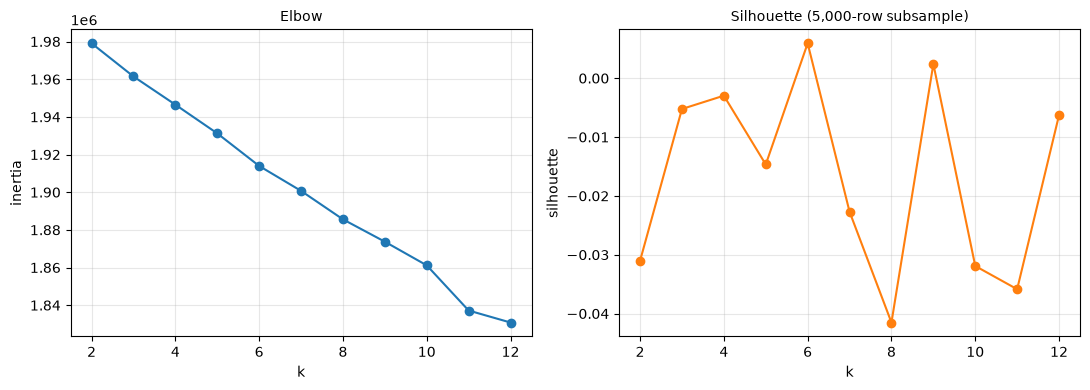

In [46]:
sweep = clustering.sweep_k(Z_train, ks=range(2, 13))
print(sweep.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sweep["k"], sweep["inertia"], "o-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow", fontsize=10); axes[0].grid(alpha=0.3)
axes[1].plot(sweep["k"], sweep["silhouette"], "o-", color="tab:orange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette")
axes[1].set_title("Silhouette (5,000-row subsample)", fontsize=10)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "cluster_selection.png", dpi=120)
plt.show()

## 4. The stability gate

**Everything downstream depends on this cell.** K-means with a different seed starts from
different centroids; if the resulting partitions do not agree, the clusters are an
artifact of initialisation and a leave-one-cluster-out protocol built on them measures
noise dressed up as domain transfer.

Adjusted Rand index above roughly 0.8 across seed pairs is the bar. Below it, either
change `K` or abandon the grouped protocol and say so in the report. Do not lower the bar
after seeing the number.

In [47]:
K = 3  # set from section 3

stab = clustering.stability(Z_train, k=K, seeds=(42, 43, 44))
print(stab.round(4).to_string(index=False))

min_ari = float(stab["ari"].min())
STABLE = min_ari > 0.8
print(f"\nminimum pairwise ARI {min_ari:.4f}  ->  "
      f"{'stable, protocol is usable' if STABLE else 'UNSTABLE'}")
if not STABLE:
    print("Do not proceed to notebook 14 on these clusters. Try a different K, or "
          "report that the training rows do not partition into stable domains.")



 seed_a  seed_b    ari
     42      43 0.9838
     42      44 0.9708
     43      44 0.9703

minimum pairwise ARI 0.9703  ->  stable, protocol is usable


In [48]:
train_labels, test_labels, km = clustering.fit_clusters(Z_train, Z_test, k=K)
print(f"train cluster sizes: {pd.Series(train_labels).value_counts().sort_index().to_dict()}")
print(f"test  cluster sizes: {pd.Series(test_labels).value_counts().sort_index().to_dict()}")

train cluster sizes: {0: 4215, 1: 6126, 2: 9659}
test  cluster sizes: {0: 2985, 1: 1827, 2: 2187}


## 5. What are the clusters?

Three questions, in order of how much they would tell us:

1. **Do the clusters recover the id groups without being told?** The 1,999 UUID and 5,000
   numeric test rows are known to be different populations. If clustering on style alone
   separates them, that is strong evidence the clusters are tracking real document types
   rather than arbitrary partitions of a blob.
2. **Do clusters differ in class balance?** The paper's corpora range from 46.5% machine
   (CUDRT) to 82.8% (MixSet). Clusters that all sit near the global 62.5% are not tracking
   anything useful for per-cluster share.
3. **Where does the test mass land?** A cluster holding a lot of test and almost no train
   is a domain the models have effectively never seen, and is where the score is going.

In [49]:
groups_test = text.id_group(test_ids)
contingency = pd.crosstab(pd.Series(test_labels, name="cluster"),
                          pd.Series(groups_test, name="id_group"))
contingency["purity"] = contingency.max(axis=1) / contingency.sum(axis=1)
print("Test rows: cluster against id group")
print(contingency.round(3).to_string())
print(f"\nmean purity {contingency['purity'].mean():.3f} "
      "(1.0 would mean clustering perfectly recovers the id split)")

Test rows: cluster against id group
id_group  numeric  uuid  purity
cluster                        
0            2551   434   0.855
1            1186   641   0.649
2            1263   924   0.578

mean purity 0.694 (1.0 would mean clustering perfectly recovers the id split)


In [50]:
cover = clustering.coverage(train_labels, test_labels)
print(cover.round(4).to_string(index=False))
print("\nratio = frac_test / frac_train. Large means test-heavy and under-trained: "
      "documents like these are rare in training and common in the thing being scored.")

 cluster  n_train  n_test  frac_train  frac_test  ratio
       0     4215    2985      0.2108     0.4265 2.0237
       1     6126    1827      0.3063     0.2610 0.8522
       2     9659    2187      0.4830     0.3125 0.6470

ratio = frac_test / frac_train. Large means test-heavy and under-trained: documents like these are rare in training and common in the thing being scored.


## 6. Which documents do we get wrong?

Joins the round-4 out-of-fold predictions back to the training rows by cluster. This is
the first per-row error analysis in the project.

The out-of-fold scores cover `dev_idx` only (16,000 of the 20,000 rows), so the clusters
are subset to those rows before joining.

In [51]:
dev_idx = np.load(paths.DATA_PROCESSED / "dev_idx.npy")
y_dev = y[dev_idx]
dev_clusters = train_labels[dev_idx]

available = tuning.available_oof()
print(available.to_string(index=False))

oof_scores = tuning.load_oof("lightgbm") if len(available) else None
report = clustering.cluster_report(dev_clusters, y_dev, oof_scores=oof_scores)
print()
print(report.round(4).to_string(index=False))

if oof_scores is not None:
    spread = report["error_rate"].max() - report["error_rate"].min()
    print(f"\nerror-rate spread across clusters: {spread:.4f}")
    print("A wide spread means difficulty is concentrated in particular document types, "
          "which is both a target for improvement and a warning that a single global "
          "threshold is a compromise across very different sub-problems.")

           member    owner     n
     complementnb   jovyan 16000
       extratrees   jovyan 16000
         lightgbm cliffton 16000
        linearsvc    brian 16000
logreg_elasticnet    brian 16000
          xgboost     koko 16000

 cluster    n  frac_of_train  machine_share  error_rate  macro_f1
       0 3359         0.2099         0.6907      0.1176    0.8602
       1 4921         0.3076         0.6275      0.2083    0.7736
       2 7720         0.4825         0.5952      0.3057    0.6857

error-rate spread across clusters: 0.1881
A wide spread means difficulty is concentrated in particular document types, which is both a target for improvement and a warning that a single global threshold is a compromise across very different sub-problems.


In [52]:
# What does the hardest cluster actually contain? Read the documents rather than
# guessing from the statistics.
if oof_scores is not None:
    worst = int(report.sort_values("error_rate", ascending=False).iloc[0]["cluster"])
    print(f"hardest cluster: {worst}\n")
    rows = np.flatnonzero(dev_clusters == worst)[:3]
    for r in rows:
        doc = train_texts[dev_idx][r]
        print(f"--- label={y_dev[r]}  {len(doc)} chars")
        print(repr(doc[:300]))
        print()

hardest cluster: 2

--- label=0  740 chars
'The gastronomic symbol of the region is undoubtedly the Choucroute, a local variety of Sauerkraut. The word Sauerkraut in Alsatian has the form surkrut, same as in other southwestern German dialects, and means "sour cabbage" as its Standard German equivalent. This word was included into the French l'

--- label=0  288 chars
'Thanks for the interesting paper!\n\nIt seems you may have missed some very relevant early prior work on variational inference for nonlinear state-space models in Valpola and Karhunen (Neural Computation 2002, doi:10.1162/089976602760408017) further developed in Honkela et al. (JMLR 2010).'

--- label=1  283 chars
'I believe that politicians deserve to be taken out of context because they are constantly changing their opinions to fit what the majority of people want to hear. If we took them out of context, we would be able to see their true colors and how they really feel about certain issues.'



## 7. Per-cluster share (gated)

The project applies one predicted share to all 6,999 test rows. The paper's corpora range
from 46.5% to 82.8% machine, so if the clusters track the corpora, a single global cut is
a compromise.

**This is the most speculative thing in round 5 and it is gated deliberately.** Share is
the lever where a mistake costs the most, and per-cluster share cannot be validated
locally at all. Only proceed if the clusters are stable (section 4), reasonably pure
against the id groups (section 5), and differ in class balance (section 6). Otherwise
this is fitting noise on the most dangerous axis available.

In [53]:
PURE = float(contingency["purity"].mean()) > 0.75
VARIED = float(report["machine_share"].std()) > 0.05
GATE = STABLE and PURE and VARIED

print(f"stable (ARI > 0.8):                {STABLE}")
print(f"pure against id groups (> 0.75):   {PURE}")
print(f"class balance varies (std > 0.05): {VARIED}")
print(f"\nper-cluster share is {'ENABLED' if GATE else 'DISABLED'}")

if not GATE:
    print("\nLeave the global share alone. Notebook 11's id-group split is the "
          "defensible version of this idea and needs no clustering.")
else:
    print("\nProceed, but bracket the targets rather than betting one submission on a "
          "point estimate, and keep notebook 11's result as the control.")

stable (ARI > 0.8):                True
pure against id groups (> 0.75):   False
class balance varies (std > 0.05): False

per-cluster share is DISABLED

Leave the global share alone. Notebook 11's id-group split is the defensible version of this idea and needs no clustering.


## 8. Save the cluster labels

Notebook 14 consumes these. Saved with the gate outcomes alongside, so a later reader
knows whether the protocol was trustworthy at the time it was used.

In [54]:
out = paths.DATA_PROCESSED / "domain_clusters.npz"
np.savez_compressed(out, train_labels=train_labels, test_labels=test_labels,
                    dev_labels=dev_clusters, k=np.int64(K))

meta = {"k": K, "min_ari": min_ari, "stable": bool(STABLE),
        "mean_purity_vs_id_group": float(contingency["purity"].mean()),
        "machine_share_std": float(report["machine_share"].std()),
        "per_cluster_share_enabled": bool(GATE),
        "svd_explained_variance": red["explained"],
        "train_sizes": pd.Series(train_labels).value_counts().sort_index().to_dict()}
(paths.DATA_PROCESSED / "domain_clusters.json").write_text(json.dumps(meta, indent=2))

print(json.dumps(meta, indent=2))
print(f"\nsaved {out.name} and domain_clusters.json")

{
  "k": 3,
  "min_ari": 0.9702842716401743,
  "stable": true,
  "mean_purity_vs_id_group": 0.6937538030610888,
  "machine_share_std": 0.04856134407566119,
  "per_cluster_share_enabled": false,
  "svd_explained_variance": 1.0000001192092896,
  "train_sizes": {
    "0": 4215,
    "1": 6126,
    "2": 9659
  }
}

saved domain_clusters.npz and domain_clusters.json


## Discussion / carry-forward -> `14_ablation.ipynb`

_Fill in once the clusters exist._

**Report the stability number first.** Everything else in round 5's transfer argument
rests on it, and a reader should not have to hunt for it.

**Then the three findings:**

1. **Purity against the id groups.** If clustering on style alone separates UUID from
   numeric rows without being told, that independently corroborates the paper's account
   of how the test set was built, and it is a genuinely nice result for the report.
2. **The coverage ratio.** Name the cluster with the highest test-to-train ratio and what
   kind of document it holds. That is the concrete shape of the distribution shift, and
   it is far more informative than "there is a train/test gap".
3. **The error-rate spread.** If some clusters are at 15% error and others at 35%, say so
   and say which. Notebook 07 and notebook 10 both asked which *models* disagree; this is
   the first time the project can say which *documents* are hard.

**Carry forward:** `domain_clusters.npz` holds the labels and
`clustering.cluster_cv(labels, y)` turns them into leave-one-cluster-out folds. Notebook
14 scores every feature family under both that and the standard protocol, and ships on the
grouped number.

**If the stability gate failed**, that is the carry-forward: notebook 14 cannot use the
grouped protocol, its selection falls back to standard CV, and the round-5 conclusion is
limited to whatever notebooks 11 and 12 established on their own. Write that down rather
than quietly running 14 anyway.